<a href="https://colab.research.google.com/github/Swastika200105/Detecting-spam-emails/blob/main/SMS_spam_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

SMS Spam Detection Using TensorFlow in Python
**bold text**
---



In [81]:
#import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import tensorflow_hub as hub


In [82]:
# Load the dataset
df = pd.read_csv('/content/spam.csv', encoding='latin-1')
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [83]:
#clean the dataset and encode labels
df = df.drop(['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], axis=1)
df = df.rename(columns={'v1': 'label', 'v2': 'Text'})
df['label_encode'] = df['label'].map({'ham': 0, 'spam': 1})
df.head()


,label,Text,label_encode
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


In [84]:
# Split data and convert to numpy arrays
X_train, X_test, y_train, y_test = train_test_split(
    df['Text'],
    df['label_encode'],
    test_size=0.2,
    random_state=42
)
X_train_np = X_train.to_numpy()
X_test_np = X_test.to_numpy()
y_train_np = y_train.to_numpy()
y_test_np = y_test.to_numpy()

In [85]:
# Compute text Statistics for Vectorization
avg_words_len = round(sum([len(i.split())
for i in df['Text']]) / len(df['Text']))
total_words_length = len(set(" ".join(df['Text']).split()))

print(f"Data Loaded, Training samples: {len(X_train_np)}")
print(f"Average words per message: {avg_words_len}")
print(f"Approximate vocabulary size: {total_words_length}")


Data Loaded, Training samples: 4457
Average words per message: 16
Approximate vocabulary size: 15686


In [86]:
#Helper functions for training and evaluation
def compile_and_fit(model, epochs=5):
  model.compile(
      optimizer='adam',
      loss='binary_crossentropy',
      metrics=['accuracy']
  )
  history = model.fit(
      X_train_np,
      y_train_np,
      epochs=epochs,
      validation_data=(X_test_np, y_test_np)
  )
  return history
def get_metrics(model, X, y):
  y_preds = np.round(model.predict(X))
  return {
      'accuracy': accuracy_score(y, y_preds),
      'precision': precision_score(y, y_preds),
      'recall': recall_score(y, y_preds),
      'f1-score': f1_score(y, y_preds)
  }


In [87]:
#create the TextVectorization layer
from tensorflow.keras.layers import TextVectorization
text_vec = TextVectorization(
    max_tokens=total_words_length,
    standardize='lower_and_strip_punctuation',
    output_mode='int',
    output_sequence_length=avg_words_len
)
text_vec.adapt(X_train_np)

In [88]:
# model1 Dense embedding model (build and train)

input_layer = layers.Input(shape=(1,), dtype=tf.string)
X = text_vec(input_layer)
X = layers.Embedding(input_dim=total_words_length, output_dim=128)(X)
X = layers.GlobalAveragePooling1D()(X)
X = layers.Dense(32, activation='relu')(X)
output_layer = layers.Dense(1, activation='sigmoid')(X)

model_1 = keras.Model(input_layer, output_layer, name="Dense_Model")
history_1 = compile_and_fit(model_1)


Epoch 1/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 8s 40ms/step - accuracy: 0.9087 - loss: 0.2790 - val_accuracy: 0.9596 - val_loss: 0.1397
Epoch 2/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.9789 - loss: 0.0850 - val_accuracy: 0.9749 - val_loss: 0.0783
Epoch 3/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.9901 - loss: 0.0400 - val_accuracy: 0.9758 - val_loss: 0.0674
Epoch 4/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.9942 - loss: 0.0242 - val_accuracy: 0.9794 - val_loss: 0.0630
Epoch 5/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.9971 - loss: 0.0157 - val_accuracy: 0.9794 - val_loss: 0.0650


In [89]:
# Model 2 - BIdirectional LSTM model (build and train)
input_layer = layers.Input(shape=(1,), dtype=tf.string)
X = text_vec(input_layer)
X = layers.Embedding(input_dim=total_words_length, output_dim=128)(X)
X = layers.Bidirectional(layers.LSTM(64, return_sequences= True))(X)
X = layers.Bidirectional(layers.LSTM(64))(X)
X = layers.Flatten()(X)
X = layers.Dropout(0.5)(X)
output_layer = layers.Dense(1, activation='sigmoid')(X)

model_2 = keras.Model(input_layer, output_layer, name="BiLSTM_Model")
history_2 = compile_and_fit(model_2)

Epoch 1/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 19s 77ms/step - accuracy: 0.9419 - loss: 0.1672 - val_accuracy: 0.9713 - val_loss: 0.1089
Epoch 2/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 19s 67ms/step - accuracy: 0.9910 - loss: 0.0356 - val_accuracy: 0.9803 - val_loss: 0.0825
Epoch 3/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 10s 73ms/step - accuracy: 0.9951 - loss: 0.0176 - val_accuracy: 0.9812 - val_loss: 0.0769
Epoch 4/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 10s 74ms/step - accuracy: 0.9991 - loss: 0.0050 - val_accuracy: 0.9803 - val_loss: 0.0988
Epoch 5/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 10s 68ms/step - accuracy: 0.9993 - loss: 0.0041 - val_accuracy: 0.9812 - val_loss: 0.1006


In [90]:
#Model 3 - Transfer learning with Universal sentence Encoder (build and train)
use_layer = hub.KerasLayer(
    "https://tfhub.dev/google/universal-sentence-encoder/4",
    trainable = False,
    input_shape = [],
    dtype = tf.string,
    name = 'USE'
)
input_layer = layers.Input(shape = [], dtype=tf.string)
embedding = layers.Lambda(lambda X: use_layer(X), output_shape=(512,))(input_layer)
X =layers.Dense(64, activation='relu')(embedding)
X = layers.Dropout(0.2)(X)
output_layer = layers.Dense(1, activation='sigmoid')(X)

model_3 = keras.Model(input_layer, output_layer, name="USE_Model")
history_3 = compile_and_fit(model_3)

Epoch 1/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - accuracy: 0.9246 - loss: 0.2763 - val_accuracy: 0.9722 - val_loss: 0.1069
Epoch 2/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9785 - loss: 0.0792 - val_accuracy: 0.9785 - val_loss: 0.0688
Epoch 3/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9847 - loss: 0.0549 - val_accuracy: 0.9821 - val_loss: 0.0579
Epoch 4/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9881 - loss: 0.0451 - val_accuracy: 0.9848 - val_loss: 0.0546
Epoch 5/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.9890 - loss: 0.0390 - val_accuracy: 0.9848 - val_loss: 0.0526


In [91]:
# Collect performance metrics for all models
results = {
    'Dense Embedding': get_metrics(model_1, X_test_np, y_test_np),
    'Bi-LSTM': get_metrics(model_2, X_test_np, y_test_np),
    'Transfer Learning (USE)': get_metrics(model_3, X_test_np, y_test_np)
}

results_df = pd.DataFrame(results).transpose()
print("Performance Table:")
print(results_df)


35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step
Performance Table:
                         accuracy  precision    recall  f1-score
Dense Embedding          0.979372   0.970149  0.872483  0.918728
Bi-LSTM                  0.981166   0.957143  0.899329  0.927336
Transfer Learning (USE)  0.984753   0.952055  0.932886  0.942373


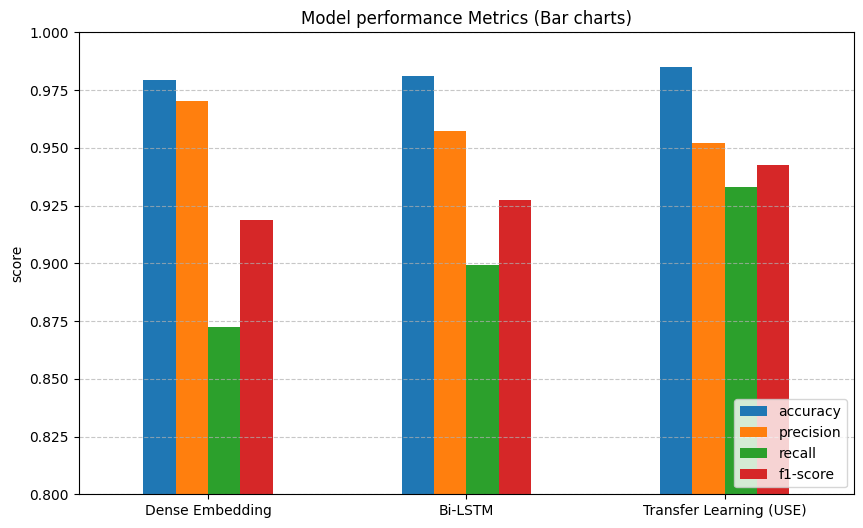

In [92]:
# Visualize the result
results_df.plot(kind='bar', figsize=(10,6))
plt.title("Model performance Metrics (Bar charts)")
plt.ylabel("score")
plt.ylim(0.8, 1.0)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

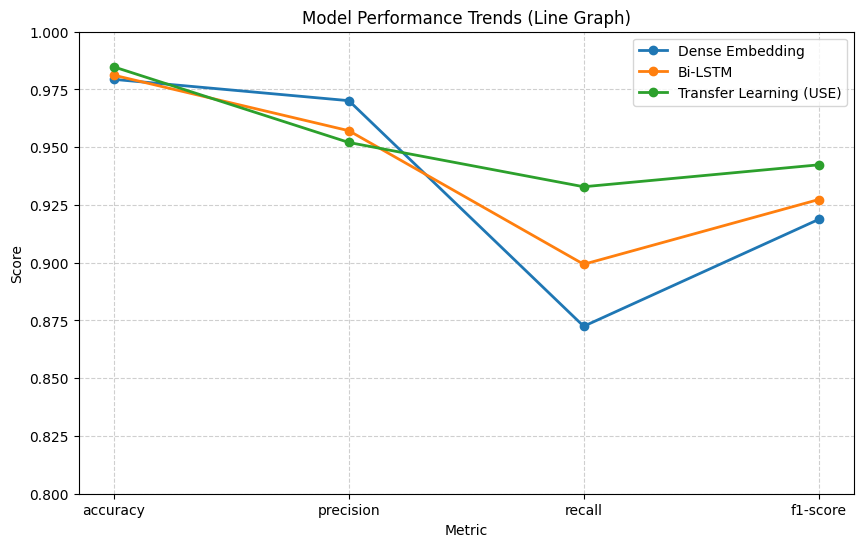

In [96]:
plt.figure(figsize=(10, 6))

for model_name in results_df.index:
    plt.plot(
        results_df.columns,
        results_df.loc[model_name],
        marker='o',
        label=model_name,
        linewidth=2
    )
plt.title("Model Performance Trends (Line Graph)")
plt.ylabel("Score")
plt.xlabel("Metric")
plt.ylim(0.8, 1.0)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()